# Hipótesis: Los niños entre 25 y 60 meses son mas propensos a contraer virus respiratorios que los que están entre 0 y 24 meses.

In [1]:
import pandas as pd

path = './Tabla_estadistica.csv'
datos_pdb = pd.read_csv(path, sep=';',decimal='.')

datos_pdb = datos_pdb[(datos_pdb["AdenoV"]=="+") | (datos_pdb["AdenoV"]=="-")]
datos_pdb = datos_pdb[(datos_pdb["RSV"]=="+")    | (datos_pdb["RSV"]=="-")]
datos_pdb = datos_pdb[(datos_pdb["INFA"]=="+")   | (datos_pdb["INFA"]=="-")]
datos_pdb = datos_pdb[(datos_pdb["INFB"]=="+")   | (datos_pdb["INFB"]=="-")]
datos_pdb = datos_pdb[(datos_pdb["PIV1"]=="+")   | (datos_pdb["PIV1"]=="-")]
datos_pdb = datos_pdb[(datos_pdb["PIV2"]=="+")   | (datos_pdb["PIV2"]=="-")]
datos_pdb = datos_pdb[(datos_pdb["PIV3"]=="+")   | (datos_pdb["PIV3"]=="-")]


In [2]:
menores = datos_pdb[datos_pdb["Edad(meses)"]<=24]
menores.head(15)
menores.describe()

,Numero,Edad(meses)
count,5559.000000,5559.000000
mean,3376.950171,6.734269
std,1946.686642,6.592539
min,2.000000,0.000000
25%,1692.500000,2.000000
50%,3310.000000,4.000000
75%,5123.500000,11.000000
max,6726.000000,24.000000


In [3]:
mayores = datos_pdb[datos_pdb["Edad(meses)"].between(25, 60)]
mayores.head(15)
mayores.describe()

,Numero,Edad(meses)
count,461.000000,461.000000
mean,3059.392625,42.887636
std,1899.490624,9.708103
min,9.000000,26.400000
25%,1176.000000,36.000000
50%,3204.000000,36.000000
75%,4586.000000,48.000000
max,6725.000000,60.000000


In [4]:
cols = ["AdenoV", "RSV", "INFA", "INFB", "PIV1", "PIV2", "PIV3"]

cantidad_positivos_menores = (menores[cols] == "+").any(axis=1).sum()

media_menores = cantidad_positivos_menores / len(menores)

print(media_menores)

0.3396294297535528


In [5]:
cols = ["AdenoV", "RSV", "INFA", "INFB", "PIV1", "PIV2", "PIV3"]

cantidad_positivos_mayores = (mayores[cols] == "+").any(axis=1).sum()

media_mayores = cantidad_positivos_mayores / len(mayores)

print(media_mayores)

0.19088937093275488


### Tabla de contingencia

Definimos la variable `Positivo`: el paciente dio positivo si al menos uno de los 7 virus dio "+". Cruzamos esa variable binaria contra el grupo etario (0-24 meses / 25-60 meses).

In [6]:
def asignar_grupo(edad):
    if edad <= 24:
        return "0-24 meses"
    elif edad <= 60:
        return "25-60 meses"
    return None

datos_pdb["Positivo"] = (datos_pdb[cols] == "+").any(axis=1)
datos_pdb["Grupo"] = datos_pdb["Edad(meses)"].apply(asignar_grupo)

datos_chi2 = datos_pdb.dropna(subset=["Grupo"])

tabla_contingencia = pd.crosstab(datos_chi2["Grupo"], datos_chi2["Positivo"])
tabla_contingencia.columns = ["Negativo", "Positivo"]
tabla_contingencia = tabla_contingencia.reindex(["0-24 meses", "25-60 meses"])
tabla_contingencia

,Negativo,Positivo
Grupo,,
0-24 meses,3671,1888
25-60 meses,373,88


In [7]:
from scipy.stats import chi2_contingency

chi2, p_valor, gl, frecuencias_esperadas = chi2_contingency(tabla_contingencia)

print(f"Chi-cuadrado = {chi2:.4f}")
print(f"p-valor = {p_valor:.2e}")
print(f"Grados de libertad = {gl}")
print("\nFrecuencias esperadas bajo H0 (independencia):")
print(pd.DataFrame(frecuencias_esperadas, index=tabla_contingencia.index, columns=tabla_contingencia.columns))

Chi-cuadrado = 42.0403
p-valor = 8.94e-11
Grados de libertad = 1

Frecuencias esperadas bajo H0 (independencia):
                Negativo     Positivo
Grupo                                
0-24 meses   3734.318272  1824.681728
25-60 meses   309.681728   151.318272


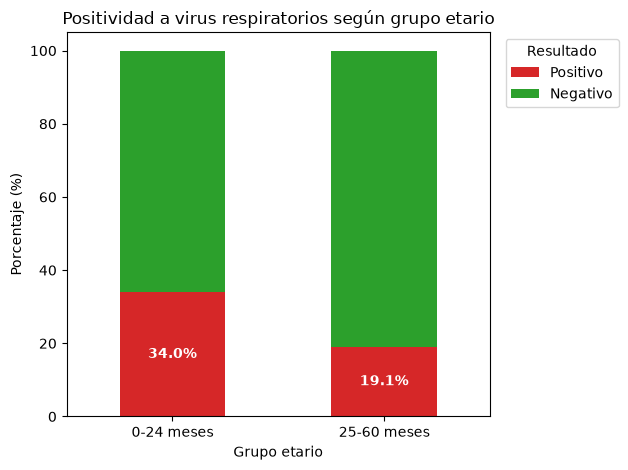

In [8]:
import matplotlib.pyplot as plt

proporciones = tabla_contingencia.div(tabla_contingencia.sum(axis=1), axis=0) * 100

ax = proporciones[["Positivo", "Negativo"]].plot(kind="bar", stacked=True, color=["#d62728", "#2ca02c"])
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("Grupo etario")
ax.set_title("Positividad a virus respiratorios según grupo etario")
ax.set_xticklabels(proporciones.index, rotation=0)

for i, grupo in enumerate(proporciones.index):
    ax.text(i, proporciones.loc[grupo, "Positivo"] / 2, f"{proporciones.loc[grupo, 'Positivo']:.1f}%",
            ha="center", va="center", color="white", fontweight="bold")

plt.legend(title="Resultado", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Conclusión

**Hipótesis nula (H0):** la positividad a virus respiratorios es independiente del grupo etario (0-24 meses vs. 25-60 meses).
**Hipótesis alternativa (H1):** la positividad depende del grupo etario.

Con α = 0.05, el test de Chi-cuadrado de independencia sobre la tabla de contingencia da χ² = 42.04, gl = 1, p ≈ 8.9×10⁻¹¹. Todas las frecuencias esperadas superan 5, así que se cumple el supuesto del test.

Como p < α, **rechazamos H0**: hay una asociación estadísticamente significativa entre el grupo etario y la positividad a virus respiratorios.

Sin embargo, el sentido de la asociación es el **opuesto** al planteado en la hipótesis original: el grupo de 0-24 meses tiene una tasa de positividad del 33.96% (1888/5559), mayor a la del grupo de 25-60 meses, que es del 19.09% (88/461). Es decir, los datos muestran que los niños más chicos (0-24 meses) son los que tienen más chances de contraer un virus respiratorio, no los de 25-60 meses.

Esto es clínicamente razonable: los virus respiratorios (en particular VSR) suelen afectar con más fuerza a los lactantes, que todavía no desarrollaron inmunidad adquirida frente a estos patógenos. Para el informe, conviene dejar esto explícito: la hipótesis original queda refutada por los datos, aunque sí se confirma que existe una asociación significativa entre edad y positividad (en sentido inverso al esperado).